# Module 1

In [85]:
import matplotlib.pyplot as plt
from skimage import io
from skimage.transform import radon, iradon
import numpy as np

## Exercise 1.1

### Data Exploration and Setup

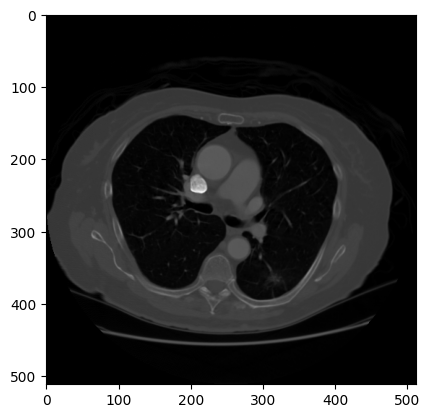

In [28]:
# fetch image data
# png is RBGA data, so convert to grayscale
im_arr = io.imread('data/CT_exercise_1.png', as_gray=True)

plt.imshow(im_arr, cmap='gray')

Shape (dimensions): (512, 512)
Number of dimensions: 2
Data type: float64
Min value: 0.0000
Max value: 1.0000
Mean value: 0.0893
Standard deviation: 0.1154
Any NaNs? False


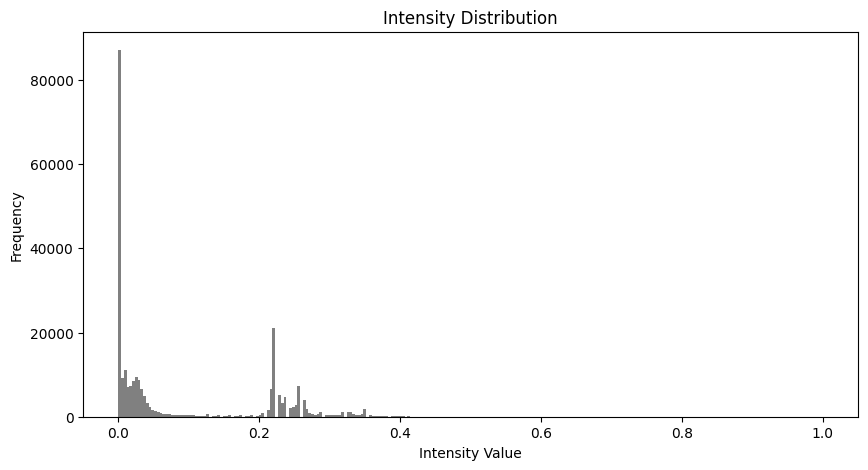

In [29]:
# Basic properties
print(f"Shape (dimensions): {im_arr.shape}")
print(f"Number of dimensions: {im_arr.ndim}")
print(f"Data type: {im_arr.dtype}")

# Intensity statistics
print(f"Min value: {im_arr.min():.4f}")
print(f"Max value: {im_arr.max():.4f}")
print(f"Mean value: {im_arr.mean():.4f}")
print(f"Standard deviation: {im_arr.std():.4f}")

print(f"Any NaNs? {np.isnan(im_arr).any()}")

# Histogram to describe the intensity distribution
plt.figure(figsize=(10, 5))
plt.hist(im_arr.ravel(), bins=256, color='gray')
plt.title("Intensity Distribution")
plt.xlabel("Intensity Value")
plt.ylabel("Frequency")
plt.show()

/Users/rowandauria/Documents/MPhil/Medical Imaging/A2 Coursework/A2_coursework/venv/lib/python3.12/site-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


0.0 100.62582158187095
(512, 360)


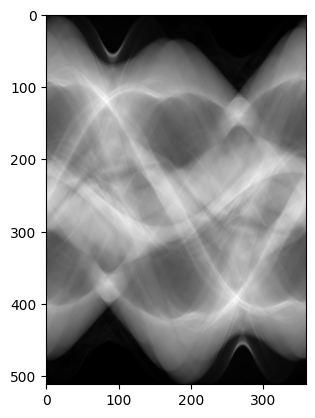

In [70]:
# Create clean sinogram
theta = np.linspace(0., 360., 360, endpoint=False)
sinogram = radon(image=im_arr, theta=theta)
print(sinogram.min(), sinogram.max())
print(sinogram.shape)

plt.imshow(sinogram, cmap='gray')

max = sinogram.max()
sinogram = sinogram/max

**NB:** The above sinogram is an absorption sinogram, not a transmission sinogram. So we need to invert the sinogram before applying noise

CHECK THE BELOW

Beer-Lambert Law: $$I = I_0 e^{-\mu x}$$

where $I$ is the intensity of the radiation after passing through the object, $I_0$ is the initial intensity of the radiation, $\mu$ is the linear attenuation coefficient of the object, and $x$ is the thickness of the object.

Invert this to get the sinogram: $$I_{attenuated} = I_0 e^{-S}$$

### b)

In [92]:
sino_dict = {'theta_360': {}}

# ---I0 = 10e2---
# Invert sinogram
I0 = 1e2
I = I0 * np.exp(-sinogram)
# Add poisson noise
I_noisy = np.random.poisson(I)
# Convert back to attenuation sinogram
sin_attn = -np.log(I_noisy/I0)
sino_dict['theta_360']['poiss_10e2'] = sin_attn

# ---I0 = 10e3---
# Invert sinogram
I0 = 1e3
I = I0 * np.exp(-sinogram)
# Add poisson noise
I_noisy = np.random.poisson(I)
# Convert back to attenuation sinogram
sin_attn = -np.log(I_noisy/I0)
sino_dict['theta_360']['poiss_10e3'] = sin_attn

# ---I0 = 10e5---
# Invert sinogram
I0 = 1e5
I = I0 * np.exp(-sinogram)
# Add poisson noise
I_noisy = np.random.poisson(I)
# Convert back to attenuation sinogram
sin_attn = -np.log(I_noisy/I0)
sino_dict['theta_360']['poiss_10e5'] = sin_attn

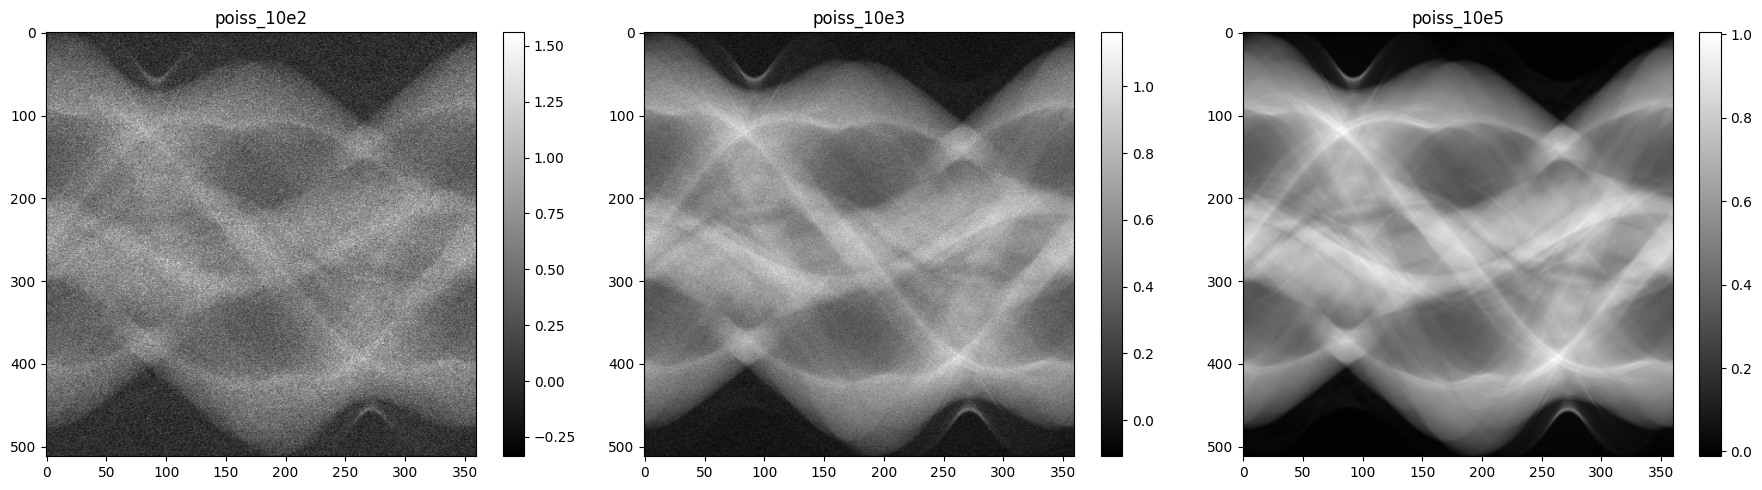

In [93]:
# Retrieve the 3 sinograms
sinograms = sino_dict['theta_360']

# Check if the data is stored as a dictionary (with specific names)
# or as a list/array, so we can label the plots appropriately
if isinstance(sinograms, dict):
    titles = list(sinograms.keys())
    images = list(sinograms.values())
else:
    titles = [f'Sinogram {i+1}' for i in range(len(sinograms))]
    images = sinograms

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, ax in enumerate(axes):
    # aspect='auto' is often useful for sinograms since the number of
    # angles and detectors might be quite different
    im = ax.imshow(images[i], cmap='gray', aspect='auto')
    ax.set_title(titles[i])

    # Add a colorbar for each individual sinogram
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()



### c)

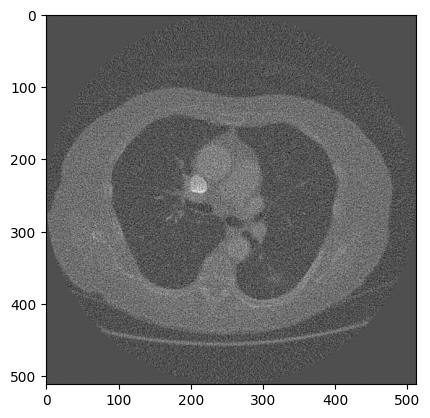

In [86]:
recon = iradon(sino_dict['poiss_10e2'], theta=theta, circle=True)
plt.imshow(recon, cmap='gray')

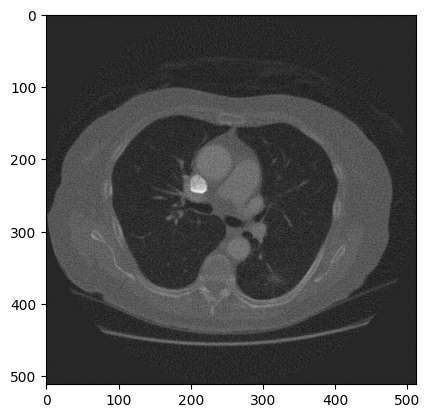

In [87]:
recon = iradon(sino_dict['poiss_10e5'], theta=theta, circle=True)
plt.imshow(recon, cmap='gray')